In [1]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
              -28, -50, 60, -100, -10, -11, 13, 19, 1, 9])

In [3]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda, _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [4]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt

Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC

print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


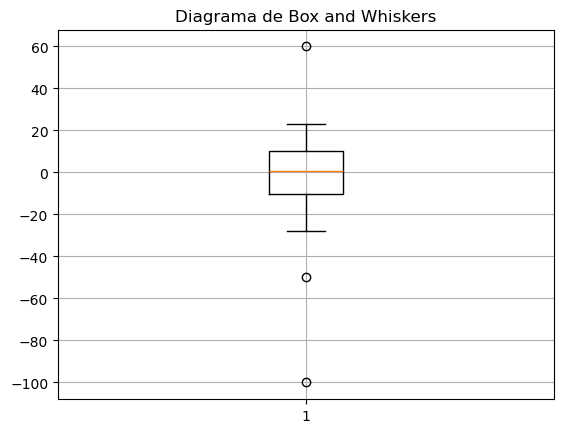

In [7]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
# # 1. Cálculo de medidas de posición 
# Q1 = np.percentile(X, 25)
# Q3 = np.percentile(X, 75)
# RIC = Q3 - Q1  # Rango Intercuartílico

# # 2. Determinación de límites para outliers
# lim_inf = Q1 - 1.5 * RIC
# lim_sup = Q3 + 1.5 * RIC

# # 3. Identificación de outliers
# outliers = X[(X < lim_inf) | (X > lim_sup)]
# print(f"Rango Intercuartílico (RIC): {RIC}")
# print(f"Límite Inferior (Li): {lim_inf}")
# print(f"Límite Superior (Ls): {lim_sup}")
# print(f"Outliers detectados: {outliers}")
# print(f"Número de outliers: {len(outliers)}")

# # 4. Dibujo del diagrama de Box and Whiskers
# plt.boxplot(X, vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
# plt.title('Diagrama de Box and Whiskers')
# plt.xlabel('Valores de X')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()

plt.boxplot(X)
plt.title('Diagrama de Box and Whiskers')
plt.grid()
plt.show()

In [8]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [9]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [12]:
from sklearn import datasets
from scipy.stats import skew, kurtosis

# 1. Cargar el set de datos de Iris
iris = datasets.load_iris()

# 2. Asignación de variables
# X contiene las características (features) y y las etiquetas (target) [cite: 1647, 1703]
X = iris.data
y = iris.target

# 3. Análisis de "longitud del pétalo" (Indice 2 en Iris)
# Calculamos el coeficiente de asimetría [cite: 1853, 1856]
asimetria_petalo = skew(X[:, 2])
print(f'Asimetría longitud del pétalo: {asimetria_petalo:.4f}')
if asimetria_petalo>0:
    print('la cola de la distribución se extiende hacia la derecha de la media aritmética.')
else:
    print('la cola de la distribución se extiende hacia la izquierda de la media aritmética.')

# 4. Análisis de "ancho del sépalo" (Indice 1 en Iris)
# Calculamos la curtosis [cite: 1854, 1857]
curtosis_sepalo = kurtosis(X[:, 1])
print(f'Curtosis ancho del sépalo: {curtosis_sepalo:.4f}')

if curtosis_sepalo>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría longitud del pétalo: -0.2721
la cola de la distribución se extiende hacia la izquierda de la media aritmética.
Curtosis ancho del sépalo: 0.1810
Distribución Leptocúrtica


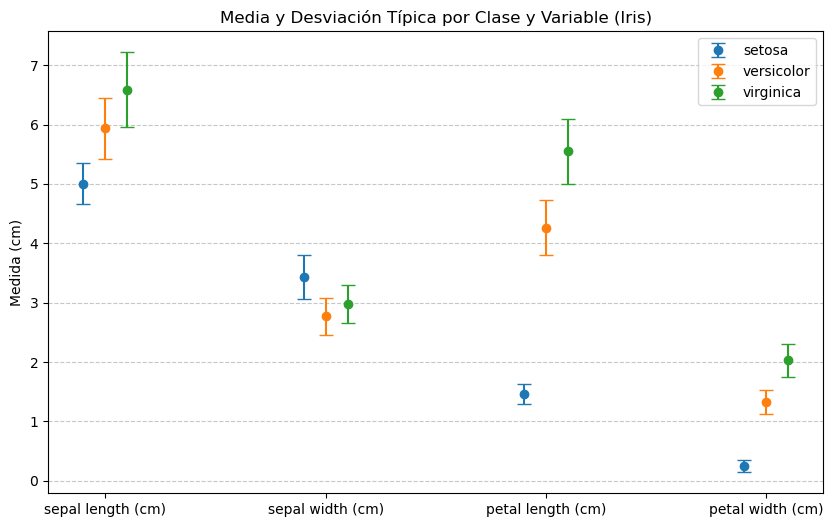

In [13]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (plt.errorbar)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# 1. Cargar el set de datos de Iris
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 2. Extraer media y desviación típica por clase y variable
means = []
stds = []

for i in range(len(target_names)):
    class_data = X[y == i]
    # Calculamos la media (Pág. 14) y la desviación típica (Pág. 15)
    means.append(np.mean(class_data, axis=0))
    stds.append(np.std(class_data, axis=0))

means = np.array(means)
stds = np.array(stds)

# 3. Representación en un gráfico (plt.errorbar)
x_indices = np.arange(len(feature_names))
plt.figure(figsize=(10, 6))

for i in range(len(target_names)):
    # Desplazamiento en X para evitar solapamiento visual
    plt.errorbar(x_indices + (i - 1) * 0.1, means[i], yerr=stds[i], 
                 fmt='o', capsize=5, label=target_names[i])

plt.xticks(x_indices, feature_names)
plt.ylabel('Medida (cm)')
plt.title('Media y Desviación Típica por Clase y Variable (Iris)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

El resultado debería ser algo como esto:
<img src="images/errorbar.png">

Interpretación de cara al Aprendizaje Supervisado\
Este tipo de representación es fundamental en la fase de Extracción de características. Permite observar visualmente la separabilidad de las clases:

Las variables de pétalo (petal length y petal width) muestran una clara distinción entre las clases, lo que las convierte en características altamente discriminativas para un modelo de clasificación supervisada.

Las variables de sépalo presentan mayor solapamiento, lo que indica que por sí solas podrían ser menos eficaces para diferenciar entre versicolor y virginica.